In [ ]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data = pd.read_csv("placement_dataset.csv")

print("Dataset Shape:", data.shape)
print(data.head())


Dataset Shape: (5000, 13)
   student_id  tenth_percentage  inter_percentage  cgpa  coding_score  \
0           1             71.11             71.93  6.79            47   
1           2             95.88             75.36  6.60            41   
2           3             86.48             91.75  5.85            35   
3           4             80.74             69.62  7.91            32   
4           5             61.71             92.39  7.29            81   

   dsa_score  projects_count  internships  aptitude_score  \
0         93               5            1              92   
1         23               2            2              69   
2         42               5            0              20   
3         33               2            1              58   
4         24               4            0              93   

   communication_skill  mock_interview_score  certifications  placement_status  
0                   82                    22               0                 1  
1     

In [ ]:
X = data.drop(["placement_status","student_id"],axis=1)


y = data["placement_status"]

print("\nFeatures used for training:")
print(X.columns)


Features used for training:
Index(['tenth_percentage', 'inter_percentage', 'cgpa', 'coding_score',
       'dsa_score', 'projects_count', 'internships', 'aptitude_score',
       'communication_skill', 'mock_interview_score', 'certifications'],
      dtype='object')


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (4000, 11)
Testing Data: (1000, 11)


In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train,y_train)

print("\nModel Training Completed")


Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("\nModel Accuracy:", accuracy*100, "%")


Model Accuracy: 93.30000000000001 %


In [ ]:
cm = confusion_matrix(y_test,y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[486  22]
 [ 45 447]]


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       508
           1       0.95      0.91      0.93       492

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



In [ ]:
print("\nFeature Importance:")

importance = model.feature_importances_

for i,v in enumerate(importance):
    print(X.columns[i],":",v)



Feature Importance:
tenth_percentage : 0.03476205406404628
inter_percentage : 0.03412932066093913
cgpa : 0.1386612276943987
coding_score : 0.2058922199637534
dsa_score : 0.21797728779889108
projects_count : 0.06424940482219334
internships : 0.04310400506232212
aptitude_score : 0.07057741896775795
communication_skill : 0.07482987331080411
mock_interview_score : 0.09871444841790693
certifications : 0.017102739236987012



Placement Prediction:
Moderate chances of placement
Placement Probability: 79.15 %

Skill Suggestions:
- Improve coding practice

Top Weak Skills:
- Coding (Score: 55)
- Communication (Score: 60)
- Aptitude (Score: 65)

Improvement Suggestions:
- Practice coding problems daily
- Improve communication and mock interviews
- Practice aptitude questions


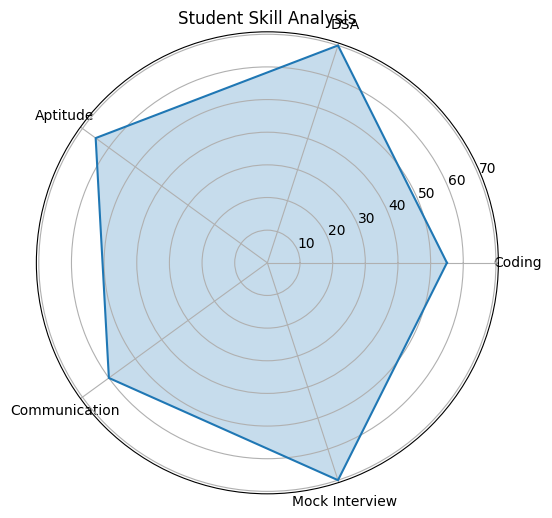

In [ ]:

sample_student = pd.DataFrame(
[[85,90,8.5,55,70,3,1,65,60,70,2]],
columns=X.columns
)


sample_student_scaled = scaler.transform(sample_student)


prediction = model.predict(sample_student_scaled)


probability = model.predict_proba(sample_student_scaled)

placement_percentage = probability[0][1] * 100

print("\nPlacement Prediction:")

if placement_percentage >= 80:
    print("High chances of getting placed")

elif placement_percentage >= 50:
    print("Moderate chances of placement")

else:
    print("Low placement chances – improve skills")

print("Placement Probability:", round(placement_percentage,2), "%")

coding = sample_student["coding_score"].values[0]
dsa = sample_student["dsa_score"].values[0]
aptitude = sample_student["aptitude_score"].values[0]
communication = sample_student["communication_skill"].values[0]

suggestion = False

print("\nSkill Suggestions:")

if coding < 60:
    print("- Improve coding practice")
    suggestion = True

if dsa < 60:
    print("- Practice DSA problems")
    suggestion = True

if aptitude < 60:
    print("- Improve aptitude skills")
    suggestion = True

if communication < 60:
    print("- Improve communication skills")
    suggestion = True

if not suggestion:
    print("All skills are good ")

skills = {
    "Coding": coding,
    "DSA": dsa,
    "Aptitude": aptitude,
    "Communication": communication
}
sorted_skills = sorted(skills.items(), key=lambda x: x[1])
weak_skills = sorted_skills[:3]
print("\nTop Weak Skills:")

for skill, score in weak_skills:
    print(f"- {skill} (Score: {score})")
print("\nImprovement Suggestions:")

for skill, score in weak_skills:

    if skill == "Coding":
        print("- Practice coding problems daily")

    elif skill == "DSA":
        print("- Solve DSA problems on LeetCode or HackerRank")

    elif skill == "Aptitude":
        print("- Practice aptitude questions")

    elif skill == "Communication":
        print("- Improve communication and mock interviews")
import matplotlib.pyplot as plt
import numpy as np


coding = sample_student["coding_score"].values[0]
dsa = sample_student["dsa_score"].values[0]
aptitude = sample_student["aptitude_score"].values[0]
communication = sample_student["communication_skill"].values[0]
mock = sample_student["mock_interview_score"].values[0]

skills = ['Coding', 'DSA', 'Aptitude', 'Communication', 'Mock Interview']
scores = [coding, dsa, aptitude, communication, mock]


scores = scores + [scores[0]]
angles = np.linspace(0, 2*np.pi, len(skills), endpoint=False).tolist()
angles = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, scores)
ax.fill(angles, scores, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), skills)
ax.set_title("Student Skill Analysis")

plt.show()

